In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
df = pd.read_csv('gsearch_jobs.csv')

In [4]:
# Check shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Rows: 61953
Columns: 27


,Unnamed: 0,index,title,company_name,location,via,description,extensions,job_id,thumbnail,...,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,0,0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']"
1,1,1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,2,2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
3,3,3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,NaN,...,NaN,15–25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']"
4,4,4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,90K–110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']"


In [5]:
# Data Cleaning
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 Unnamed: 0                 0
index                      0
title                      0
company_name               0
location                  37
via                        9
description                0
extensions                 0
job_id                     0
thumbnail              23759
posted_at                190
schedule_type            246
work_from_home         33973
salary                 51865
search_term                0
date_time                  0
search_location            0
commute_time           61953
salary_pay             51865
salary_rate            51865
salary_avg             51865
salary_min             52441
salary_max             52441
salary_hourly          56053
salary_yearly          57884
salary_standardized    51865
description_tokens         0
dtype: int64

Duplicate rows: 0

Data types:
 Unnamed: 0               int64
index                    int64
title                   object
company_name            object
location                object

In [6]:
# EDA - Salary Distribution
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Filter Data Analyst jobs with salary
da_jobs = df[df['title'].str.contains('Data Analyst', na=False, case=False)]
da_jobs = da_jobs[da_jobs['salary_avg'].notna()]

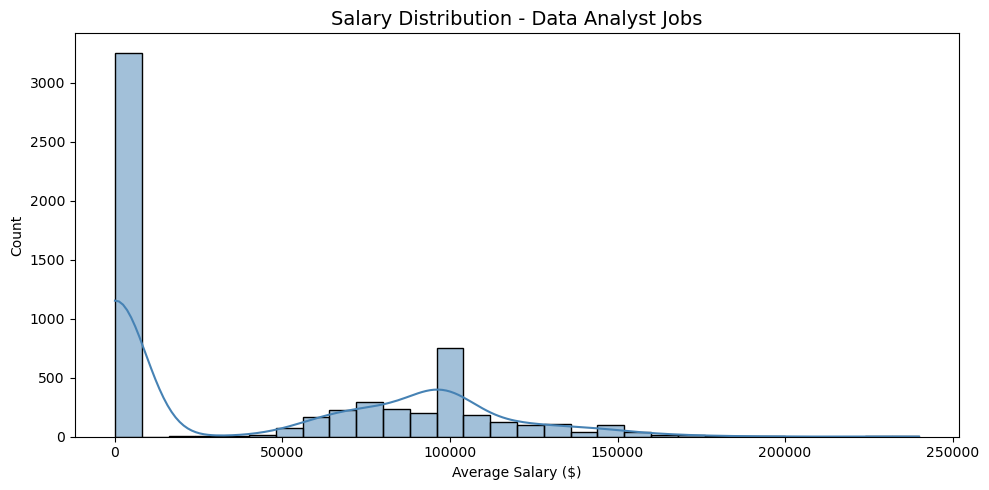

In [8]:
# Plot
plt.figure(figsize=(10, 5))
sns.histplot(da_jobs['salary_avg'], bins=30, color='steelblue', kde=True)
plt.title('Salary Distribution - Data Analyst Jobs', fontsize=14)
plt.xlabel('Average Salary ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('salary_distribution.png')
plt.show()

In [9]:
print(f"Total DA jobs with salary: {len(da_jobs)}")
print(f"Average Salary: ${da_jobs['salary_avg'].mean():,.0f}")
print(f"Max Salary: ${da_jobs['salary_avg'].max():,.0f}")
print(f"Min Salary: ${da_jobs['salary_avg'].min():,.0f}")

Total DA jobs with salary: 5974
Average Salary: $43,805
Max Salary: $240,000
Min Salary: $9


In [10]:
# Top 10 Most In-Demand Skills
import ast

# Parse description_tokens
def parse_skills(tokens):
    try:
        return ast.literal_eval(tokens)
    except:
        return []

da_jobs['skills_list'] = da_jobs['description_tokens'].apply(parse_skills)

In [11]:
# Count skills
from collections import Counter
all_skills = []
for skills in da_jobs['skills_list']:
    all_skills.extend(skills)

skill_counts = Counter(all_skills)
top_skills = pd.DataFrame(skill_counts.most_common(10), 
                           columns=['skill', 'count'])

C:\Users\c patil\AppData\Local\Temp\ipykernel_37816\4082733304.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skills, x='count', y='skill', palette='Blues_r')


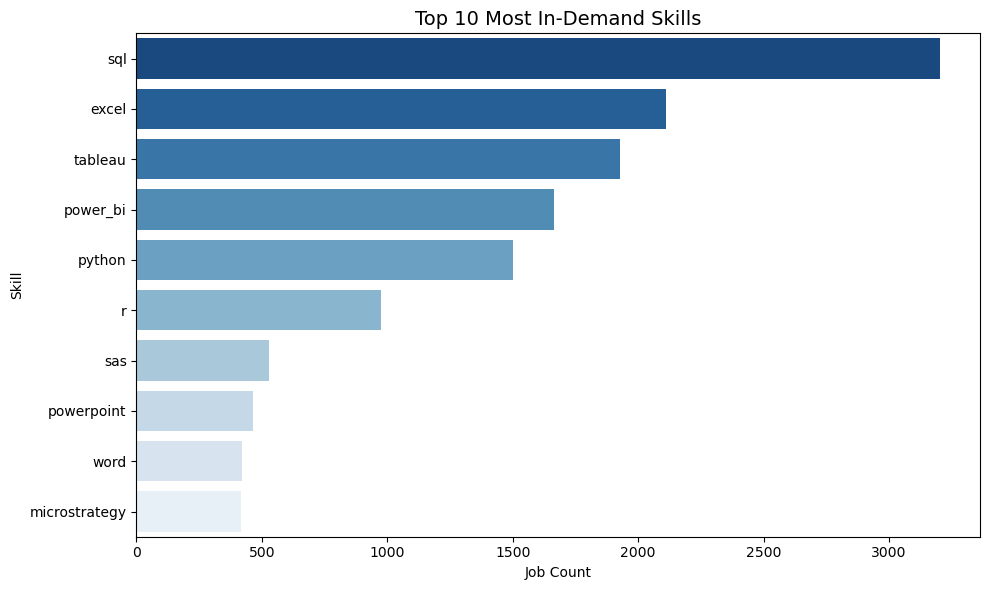

In [12]:
# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_skills, x='count', y='skill', palette='Blues_r')
plt.title('Top 10 Most In-Demand Skills', fontsize=14)
plt.xlabel('Job Count')
plt.ylabel('Skill')
plt.tight_layout()
plt.savefig('top_skills.png')
plt.show()

In [13]:
# Salary by Top Skills
skill_salary = []
for _, row in da_jobs.iterrows():
    skills = parse_skills(row['description_tokens'])
    salary = row['salary_avg']
    if pd.notna(salary):
        for skill in skills:
            skill_salary.append({'skill': skill, 'salary': salary})

skill_salary_df = pd.DataFrame(skill_salary)

In [14]:
# Top 10 skills by avg salary
top_skill_salary = (skill_salary_df.groupby('skill')['salary']
                    .agg(['mean', 'count'])
                    .reset_index()
                    .query('count > 100')
                    .sort_values('mean', ascending=False)
                    .head(10))

C:\Users\c patil\AppData\Local\Temp\ipykernel_37816\2141133436.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skill_salary, x='mean', y='skill', palette='Greens_r')


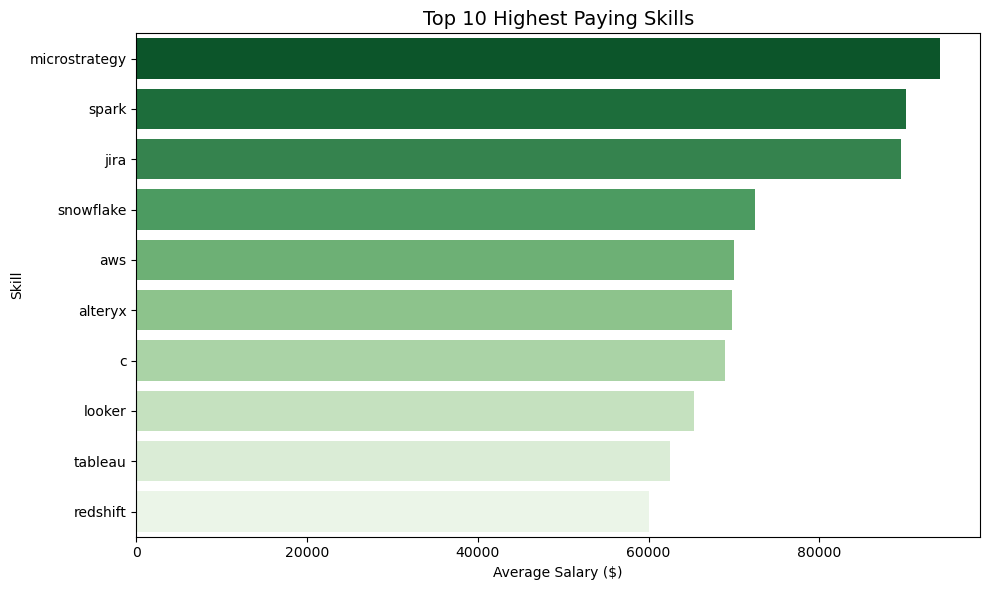

In [15]:
# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_skill_salary, x='mean', y='skill', palette='Greens_r')
plt.title('Top 10 Highest Paying Skills', fontsize=14)
plt.xlabel('Average Salary ($)')
plt.ylabel('Skill')
plt.tight_layout()
plt.savefig('skill_salary.png')
plt.show()

C:\Users\c patil\AppData\Local\Temp\ipykernel_37816\1989576297.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_counts.values, y=location_counts.index, palette='Oranges_r')


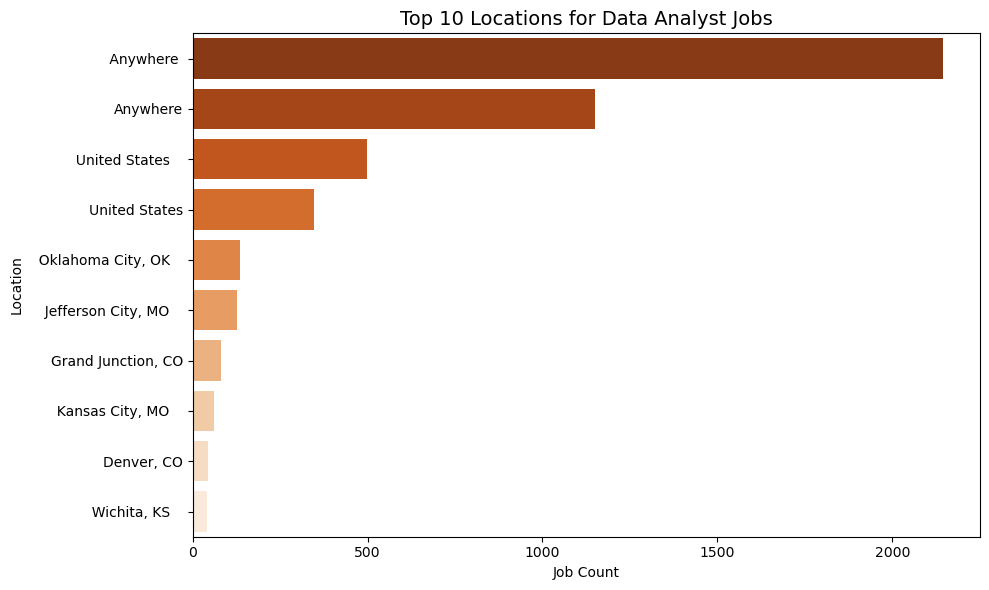

In [16]:
# Remote vs On-site Jobs
location_counts = da_jobs['location'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=location_counts.values, y=location_counts.index, palette='Oranges_r')
plt.title('Top 10 Locations for Data Analyst Jobs', fontsize=14)
plt.xlabel('Job Count')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('location_jobs.png')
plt.show()



In [17]:
# Remote percentage
remote = da_jobs[da_jobs['location'].str.contains('Anywhere', na=False)]
print(f"Remote Jobs: {len(remote)}")
print(f"Total DA Jobs: {len(da_jobs)}")
print(f"Remote %: {len(remote)/len(da_jobs)*100:.1f}%")

Remote Jobs: 3294
Total DA Jobs: 5974
Remote %: 55.1%
